In [1]:
from biolearn.data_library import GeoData,DataLibrary
from biolearn.visualize import plot_sample_deviations
from sklearn.linear_model import LinearRegression,ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
#Load some evaluation data
evaluation_data = DataLibrary().get("GSE157131").load()

In [3]:
# Print the first few rows of the data to verify it loaded correctly
print(evaluation_data.dnam.head(10))

            GSM4753639  GSM4753640  GSM4753641  GSM4753642  GSM4753644  \
ID_REF                                                                   
cg00000029    0.743143    0.706606    0.628885    0.562915    0.614170   
cg00000109    0.956468    0.953614    0.962331    0.952262    0.952814   
cg00000165    0.151411    0.127816    0.092166    0.077027    0.120263   
cg00000236    0.904720    0.874442    0.863355    0.894204    0.876077   
cg00000289    0.864994    0.845839    0.883417    0.891442    0.873706   
cg00000292    0.937064    0.942809    0.942936    0.926290    0.939766   
cg00000321    0.377977    0.334562    0.254497    0.209236    0.436616   
cg00000363    0.377921    0.328329    0.403079    0.365630    0.373116   
cg00000622    0.014657    0.012975    0.017717    0.013984    0.014756   
cg00000658    0.916058    0.908628    0.920468    0.833336    0.915868   

            GSM4753645  GSM4753646  GSM4753649  GSM4753650  GSM4753653  ...  \
ID_REF                          

In [4]:
#Load some training data
data = DataLibrary().get("GSE40279").load()
data.metadata

,age,sex,ethnicity,tissue
id,,,,
GSM989827,67.0,1,Caucasian - European,whole blood
GSM989828,89.0,1,Caucasian - European,whole blood
GSM989829,66.0,1,Caucasian - European,whole blood
GSM989830,64.0,1,Caucasian - European,whole blood
GSM989831,62.0,1,Caucasian - European,whole blood
...,...,...,...,...
GSM990623,78.0,1,Caucasian - European,whole blood
GSM990624,71.0,2,Caucasian - European,whole blood
GSM990625,68.0,2,Caucasian - European,whole blood


In [5]:
data.dnam.head()

,GSM989827,GSM989828,GSM989829,GSM989830,GSM989831,GSM989832,GSM989833,GSM989834,GSM989835,GSM989836,...,GSM990618,GSM990619,GSM990620,GSM990621,GSM990622,GSM990623,GSM990624,GSM990625,GSM990626,GSM990627
id,,,,,,,,,,,,,,,,,,,,,
cg00000029,0.464197,0.454883,0.485764,0.480785,0.501220,0.499918,0.485852,0.512442,0.518155,0.417986,...,0.560958,0.472081,0.508502,0.505193,0.443411,0.527496,0.588331,0.362994,0.499145,0.458600
cg00000108,0.941091,0.939033,0.918802,0.929908,0.934548,0.950543,0.925855,0.941330,0.938528,0.933814,...,0.934699,0.978612,0.922024,0.963052,0.992631,0.958173,0.982450,0.954392,0.931690,0.974731
cg00000109,0.911182,0.596455,0.870333,0.889689,0.890450,0.898493,0.893972,0.892010,0.900841,0.883539,...,0.881957,0.926289,0.930091,0.946547,0.929131,0.922034,0.855145,0.927184,0.900938,0.829869
cg00000165,0.132014,0.206917,0.162861,0.197780,0.148437,0.224093,0.400489,0.194553,0.134710,0.204569,...,0.199883,0.165116,0.210248,0.177351,0.118742,0.223068,0.162180,0.196430,0.167477,0.170578
cg00000236,0.717861,0.723935,0.719196,0.704061,0.754913,0.829192,0.723782,0.695142,0.731872,0.742913,...,0.759011,0.792883,0.730367,0.783830,0.787089,0.778959,0.796868,0.713020,0.730215,0.782844


In [ ]:


# Extract data from your 'data' object
X = data.dnam.transpose().values  # Transpose to have samples as rows and cpg sites as columns
y = data.metadata['age'].values

# Parameters for bootstrap and feature selection
n_bootstrap = 20
threshold = 0.05

# Store count of times each CpG site is deemed significant
cpg_counts = np.zeros(X.shape[1])

# Begin bootstrap iterations
for _ in range(n_bootstrap):
    # Sample with replacement from X, y
    sample_idx = np.random.choice(range(X.shape[0]), size=X.shape[0], replace=True)
    X_sample = X[sample_idx]
    y_sample = y[sample_idx]

    # Train model
    model = LinearRegression()
    model.fit(X_sample, y_sample)

    # Identify significant CpG sites (based on magnitude of coefficients)
    significant_cpgs = np.where(np.abs(model.coef_) > threshold)[0]
    cpg_counts[significant_cpgs] += 1

# Determine stable CpG sites
s = np.where(cpg_counts > n_bootstrap * 0.6)[0]
stable_cpg_names = data.dnam.index[stable_cpg_sites].tolist()

print(f"Stable CpG sites (associated with age in more than 60% of bootstrap samples): {stable_cpg_sites}")

Stable CpG sites (associated with age in more than 60% of bootstrap samples): [   559    705    801 ... 468607 469108 469592]


In [7]:


df = data.dnam.transpose()
df['age'] = data.metadata['age']
top_sites_df = df[stable_cpg_names]

X = top_sites_df
y = df['age']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:


model = ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=10000)
# Train the model
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error on Test Data: {mse}")

Mean Squared Error on Test Data: 26.918461199053844


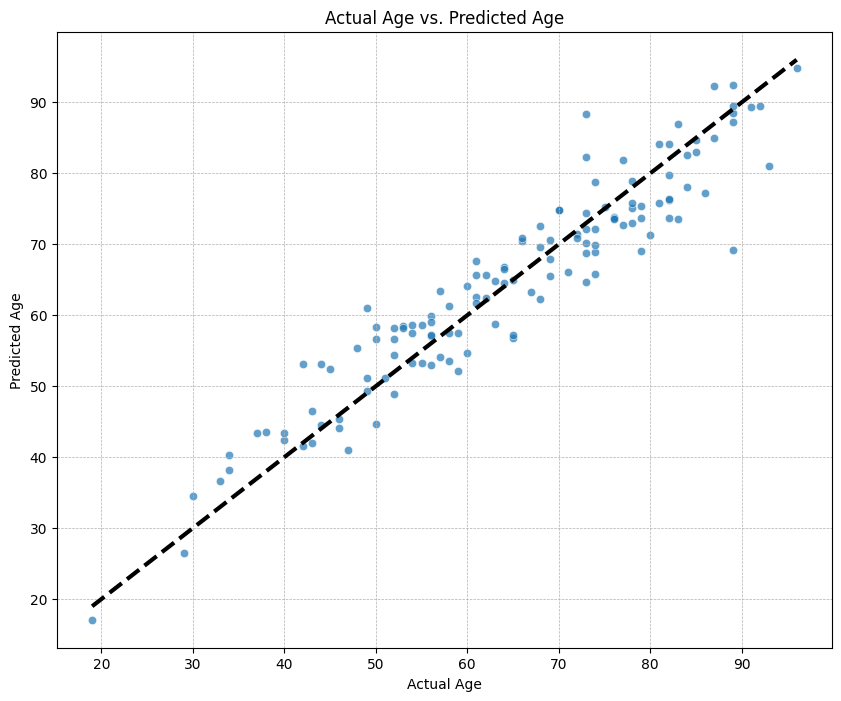

Mean Squared Error (MSE): 26.9185
Mean Absolute Error (MAE): 4.1061


In [9]:


y_pred = model.predict(X_test)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=3)  # y=x line for reference
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual Age vs. Predicted Age')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Calculate Mean Squared Error (MSE)
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error (MAE): {mae:.4f}")

In [17]:

pruned_data = evaluation_data.dnam.T
missing_cpg_sites = list(set(stable_cpg_names) - set(pruned_data.columns))
#for missing_cpg in missing_cpg_sites:
pruned_data.loc[:,missing_cpg_sites] = 0
pruned_data = pruned_data[stable_cpg_names]
#pruned_data = pruned_data.fillna(0)
challenge_results = model.predict(pruned_data)

In [ ]:
challenge_results

array([68.32336351, 60.38917408, 59.09480663, 64.87094244, 47.23155217,
       60.37813197, 73.88430631, 60.6345047 , 68.91109925, 51.31922817,
       44.93333208, 65.36860604, 54.21801788, 53.76968939, 68.07107074,
       69.26280276, 67.83197612, 64.99582041, 55.43624545, 58.74427566,
       67.1610048 , 58.31345946, 57.84388943, 59.57841908, 56.4994819 ,
       63.00916172, 72.09363079, 67.65869686, 65.91813943, 55.68362818,
       65.65794304, 59.04476983, 62.23405877, 38.26661161, 64.93371985,
       57.98635676, 73.76417344, 61.88910265, 42.10303651, 69.49512301,
       59.8105632 , 60.10157116, 49.72357307, 47.25492598, 48.70294467,
       63.83317538, 36.71053529, 72.87901712, 43.82695811, 58.81314364,
       59.04256254, 47.39640509, 63.01632683, 56.60352136, 54.05414253,
       65.83805219, 65.33766969, 60.54461571, 62.0350202 , 68.10384287,
       67.8366565 , 72.75306333, 71.87960972, 65.88297546, 49.52531096,
       40.4926548 , 53.97878278, 55.00598847, 70.07341351, 49.02

In [ ]:

predicted_age_df = pd.DataFrame({
    'predictedAge': challenge_results,
    'ActualAge' : evaluation_data.metadata.age
}, index=evaluation_data.dnam.columns)
predicted_age_df.index.name = 'sampleId'
predicted_age_df

,predictedAge,ActualAge
sampleId,,
GSM1051525,68.323364,67.0
GSM1051526,60.389174,49.0
GSM1051527,59.094807,53.0
GSM1051528,64.870942,62.0
GSM1051529,47.231552,33.0
...,...,...
GSM1052209,66.098615,63.0
GSM1052210,57.312577,63.0
GSM1052211,53.086587,46.0


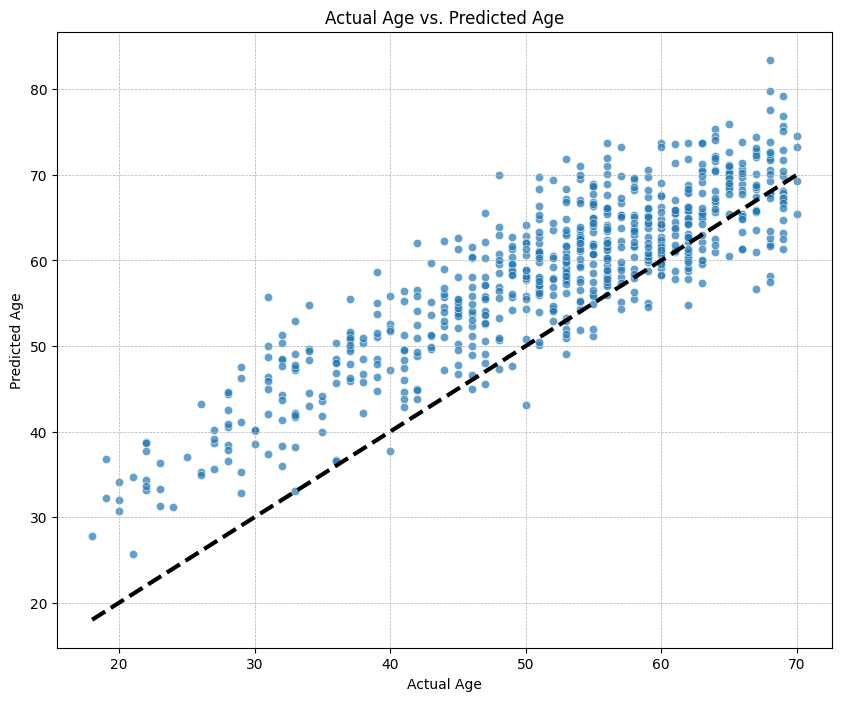

Mean Squared Error (MSE): 76.9309
Mean Absolute Error (MAE): 7.3173


In [ ]:
y_pred = challenge_results
y_test = evaluation_data.metadata.age
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=3)  # y=x line for reference
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual Age vs. Predicted Age')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# Calculate Mean Squared Error (MSE)
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_test - y_pred))
print(f"Mean Absolute Error (MAE): {mae:.4f}")